In [2]:

import numpy as np
import pandas as pd 
import os
from utils import loo_cv_bootstrap_nested_lasso, summarize_feature_selection
from joblib import Parallel, delayed
import re
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
font_path = "/scratch/individuals/yujie/font.ttf"
# register the font file
fm.fontManager.addfont(font_path)

# get the exact family name from the font file
font_name = fm.FontProperties(fname=font_path).get_name()
print("Using:", font_name)
plt.rcParams.update({
    "font.family": font_name,
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,

    # Set ALL linewidths to 1.0
    "lines.linewidth": 1.4,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "ytick.major.size": 1.5,
    "xtick.major.size": 1.5,
    "grid.linewidth": 0.8,
    "axes.titlepad": 0.5,
    "axes.labelpad": 1,
    "savefig.pad_inches": 0.1
})


# -------------------------
# Config
# -------------------------
C_grid =  np.logspace(-2, 1, 10)
N_JOBS_DATASETS = 5
OUTDIR = "../result/prognostic_evaluation/"
os.makedirs(OUTDIR, exist_ok=True)
# -------------------------
# Load data
# -------------------------
metadata = pd.read_csv("./data/metadata.csv", index_col=0)
nuclei_feature_unique = pd.read_csv("./data/nuclei_feature.csv", index_col=0)
glandular_feat_unique = pd.read_csv("./data/gland_feature.csv", index_col=0)
graph_feature = pd.read_csv("./data/Scale3D_feature.csv",index_col=0)

combined_nuclei_gland = pd.concat([nuclei_feature_unique, glandular_feat_unique], axis=1)
combined_x = pd.concat([nuclei_feature_unique, glandular_feat_unique, graph_feature], axis=1)

# Sanity checks
assert metadata.index.equals(nuclei_feature_unique.index)
assert metadata.index.equals(glandular_feat_unique.index)
assert metadata.index.equals(graph_feature.index)
assert metadata.index.equals(combined_nuclei_gland.index)
assert metadata.index.equals(combined_x.index)

y = metadata["5yBCR"]



Using: Arial Unicode MS


In [3]:
def run_one(name: str, X: pd.DataFrame, out_path: str):
    res = loo_cv_bootstrap_nested_lasso(
        X,
        y,
        K=20,
        C_grid=C_grid,
        inner_splits=4,
        n_bootstrap=1000,
        random_state=42,
    )

    # save result if you want
    ##np.savez_compressed(out_path, **res)

    return name, out_path, res

jobs = [
    ("nuclei", nuclei_feature_unique, os.path.join(OUTDIR, "nuclei_res.npz")),
    ("gland", glandular_feat_unique, os.path.join(OUTDIR, "gland_res.npz")),
    ("nuclei_gland", combined_nuclei_gland, os.path.join(OUTDIR, "combine_nuclei_gland_res.npz")),
    ("scale3d", graph_feature, os.path.join(OUTDIR, "scale3d_res.npz")),
    ("all", combined_x, os.path.join(OUTDIR, "combine_res_d40.npz")),
]

# -------------------------
# Run in parallel
# -------------------------
results = Parallel(n_jobs=N_JOBS_DATASETS, backend="loky", verbose=10)(
    delayed(run_one)(name, X, out_path)
    for name, X, out_path in jobs
)

res_dict = {name: res for name, out_path, res in results}
nuclei_res = res_dict["nuclei"]
gland_res = res_dict["gland"]
nuclei_gland_res = res_dict["nuclei_gland"]
scale3d_res = res_dict["scale3d"]
all_res = res_dict["all"]

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


Nested-LOOCV LASSO AUC = 0.6207
95% bootstrap CI = [0.4695, 0.7529]
Nested-LOOCV LASSO AUC = 0.6378
95% bootstrap CI = [0.5131, 0.7533]


[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:  1.4min remaining:  2.2min


Nested-LOOCV LASSO AUC = 0.6847
95% bootstrap CI = [0.5693, 0.8028]


[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:  2.0min remaining:  1.3min


Nested-LOOCV LASSO AUC = 0.7230
95% bootstrap CI = [0.6035, 0.8277]
Nested-LOOCV LASSO AUC = 0.8089
95% bootstrap CI = [0.6924, 0.9083]


[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  5.6min finished


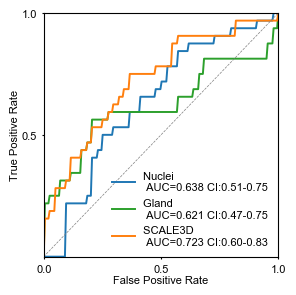

In [3]:
fig, ax = plt.subplots(figsize=(3,3))

def add_curve(res, color, label):
    plt.plot(res["mean_fpr"], res["mean_tpr"],
             label=f"{label} \n AUC={res['auc_mean']:.3f} CI:{res['auc_ci'][0]:.2f}-{res['auc_ci'][1]:.2f}",
             color=color)

add_curve(nuclei_res, "C0", "Nuclei")
add_curve(gland_res, "C2", "Gland")
add_curve(scale3d_res, "C1", "SCALE3D")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.5, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

# Keep only 0.5 tick on both axes
ax.set_xticks([0,0.5,1])
ax.set_yticks([0.5,1])

# Ensure limits are still [0, 1]
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

#ax.legend()
plt.tight_layout()
legend = ax.legend(frameon=False,loc="lower right") 
frame = legend.get_frame()
frame.set_linewidth(0.5)
plt.show()


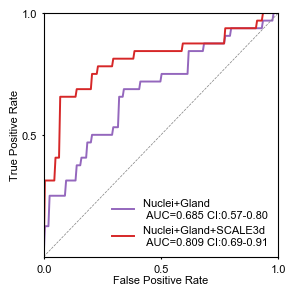

In [4]:
fig, ax = plt.subplots(figsize=(3,3))
add_curve(nuclei_gland_res, "C4", "Nuclei+Gland")
add_curve(all_res, "C3", "Nuclei+Gland+SCALE3d")

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=0.5, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

# Keep only 0.5 tick on both axes
ax.set_xticks([0,0.5,1])
ax.set_yticks([0.5,1])

# Ensure limits are still [0, 1]
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

#ax.legend()
plt.tight_layout()
legend = ax.legend(frameon=False,loc="lower right") 
frame = legend.get_frame()
frame.set_linewidth(0.5)

#plt.savefig("../figures/multi_feature_modality.pdf", bbox_inches="tight")
plt.show()


In [5]:
PERM_X = combined_x
OBS_AUC = all_res["auc_mean"]
N_JOBS_PERM = 20          
N_PERM = 500
PERM_SEED = 42


def _permute_y(y: pd.Series, rng: np.random.Generator) -> pd.Series:
    # Permute labels but keep same index for alignment
    perm = rng.permutation(y.values)
    return pd.Series(perm, index=y.index, name=y.name)

def run_one_permutation(perm_id: int) -> float:
    """
    Runs ONE permutation: shuffle y, then run full nested pipeline (including feature selection).
    Keep bootstrap smaller for runtime if needed; if you keep n_bootstrap=1000, it will be slow.
    """
    rng = np.random.default_rng(PERM_SEED + perm_id)
    y_perm = _permute_y(y, rng)

    # To keep runtime reasonable, reduce bootstrap for permutations.
    # Reviewers generally accept fewer bootstraps for permutation null estimation.
    res = loo_cv_bootstrap_nested_lasso(
        PERM_X,
        y_perm,
        K=20,
        C_grid=C_grid,
        inner_splits=4,
        n_bootstrap=200,      # <-- reduce from 1000 to speed up
        random_state=42,      # keep deterministic inside each run
    )
    auc = float(res["auc_mean"])

    # Optional: save each permutation result (can be large); usually save just AUCs
    # np.savez(os.path.join(PERM_OUTDIR, f"perm_{perm_id:04d}.npz"), res)

    # if (perm_id + 1) % 25 == 0:
    #     print(f"[perm {perm_id+1}/{N_PERM}] AUC={auc:.4f}")
    return auc

# Run permutations (parallel)
perm_aucs = Parallel(n_jobs=N_JOBS_PERM, backend="loky", verbose=10)(
    delayed(run_one_permutation)(i) for i in range(N_PERM)
)
perm_aucs = np.array(perm_aucs, dtype=float)
# Permutation p-value (add-one smoothing)
p_perm = (np.sum(perm_aucs >= OBS_AUC) + 1) / (N_PERM + 1)

summary = pd.DataFrame(
    {
        "n_perm": [N_PERM],
        "observed_auc": [OBS_AUC],
        "perm_mean_auc": [perm_aucs.mean()],
        "perm_std_auc": [perm_aucs.std(ddof=1)],
        "perm_max_auc": [perm_aucs.max()],
        "n_ge_observed": [int(np.sum(perm_aucs >= OBS_AUC))],
        "p_perm": [p_perm],
    }
)
#summary.to_csv(perm_meta_path, index=False)

print(summary)

[Parallel(n_jobs=20)]: Using backend LokyBackend with 20 concurrent workers.


Nested-LOOCV LASSO AUC = 0.3153
95% bootstrap CI = [0.1978, 0.4472]
Nested-LOOCV LASSO AUC = 0.3722
95% bootstrap CI = [0.2325, 0.5118]
Nested-LOOCV LASSO AUC = 0.6243
95% bootstrap CI = [0.4973, 0.7397]


[Parallel(n_jobs=20)]: Done   1 tasks      | elapsed:  3.9min


Nested-LOOCV LASSO AUC = 0.6683
95% bootstrap CI = [0.5392, 0.7911]
Nested-LOOCV LASSO AUC = 0.1719
95% bootstrap CI = [0.0739, 0.2755]
Nested-LOOCV LASSO AUC = 0.6555
95% bootstrap CI = [0.5453, 0.7803]
Nested-LOOCV LASSO AUC = 0.4233
95% bootstrap CI = [0.2918, 0.5242]
Nested-LOOCV LASSO AUC = 0.3388
95% bootstrap CI = [0.2149, 0.4715]
Nested-LOOCV LASSO AUC = 0.3892
95% bootstrap CI = [0.2558, 0.4983]
Nested-LOOCV LASSO AUC = 0.6463
95% bootstrap CI = [0.5130, 0.7602]


[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:  3.9min


...

[Parallel(n_jobs=20)]: Done 410 tasks      | elapsed: 95.4min


Nested-LOOCV LASSO AUC = 0.5554
95% bootstrap CI = [0.4336, 0.6741]
Nested-LOOCV LASSO AUC = 0.7074
95% bootstrap CI = [0.5793, 0.8066]
Nested-LOOCV LASSO AUC = 0.3288
95% bootstrap CI = [0.2186, 0.4540]
Nested-LOOCV LASSO AUC = 0.5426
95% bootstrap CI = [0.4146, 0.6940]
Nested-LOOCV LASSO AUC = 0.5980
95% bootstrap CI = [0.4819, 0.7191]
Nested-LOOCV LASSO AUC = 0.3217
95% bootstrap CI = [0.2149, 0.4447]
Nested-LOOCV LASSO AUC = 0.2812
95% bootstrap CI = [0.1776, 0.4227]
Nested-LOOCV LASSO AUC = 0.3928
95% bootstrap CI = [0.2363, 0.5503]
Nested-LOOCV LASSO AUC = 0.4503
95% bootstrap CI = [0.3262, 0.5844]
Nested-LOOCV LASSO AUC = 0.6605
95% bootstrap CI = [0.5357, 0.7834]
Nested-LOOCV LASSO AUC = 0.4737
95% bootstrap CI = [0.3541, 0.5824]
Nested-LOOCV LASSO AUC = 0.6101
95% bootstrap CI = [0.4812, 0.7466]
Nested-LOOCV LASSO AUC = 0.4879
95% bootstrap CI = [0.3576, 0.6078]
Nested-LOOCV LASSO AUC = 0.5085
95% bootstrap CI = [0.3638, 0.6452]
Nested-LOOCV LASSO AUC = 0.6193
95% bootstrap CI

[Parallel(n_jobs=20)]: Done 441 tasks      | elapsed: 104.6min


Nested-LOOCV LASSO AUC = 0.2365
95% bootstrap CI = [0.1358, 0.3370]
Nested-LOOCV LASSO AUC = 0.3040
95% bootstrap CI = [0.1814, 0.4112]
Nested-LOOCV LASSO AUC = 0.4531
95% bootstrap CI = [0.3212, 0.5789]
Nested-LOOCV LASSO AUC = 0.2202
95% bootstrap CI = [0.1130, 0.3379]
Nested-LOOCV LASSO AUC = 0.6484
95% bootstrap CI = [0.5254, 0.7536]
Nested-LOOCV LASSO AUC = 0.5014
95% bootstrap CI = [0.3697, 0.6577]
Nested-LOOCV LASSO AUC = 0.4972
95% bootstrap CI = [0.3918, 0.6383]
Nested-LOOCV LASSO AUC = 0.4531
95% bootstrap CI = [0.3330, 0.5820]
Nested-LOOCV LASSO AUC = 0.3885
95% bootstrap CI = [0.2640, 0.5093]
Nested-LOOCV LASSO AUC = 0.2834
95% bootstrap CI = [0.1769, 0.4054]
Nested-LOOCV LASSO AUC = 0.6264
95% bootstrap CI = [0.5133, 0.7597]
Nested-LOOCV LASSO AUC = 0.4560
95% bootstrap CI = [0.3277, 0.5929]
Nested-LOOCV LASSO AUC = 0.4283
95% bootstrap CI = [0.2950, 0.5834]
Nested-LOOCV LASSO AUC = 0.4134
95% bootstrap CI = [0.2838, 0.5378]
Nested-LOOCV LASSO AUC = 0.4659
95% bootstrap CI

[Parallel(n_jobs=20)]: Done 500 out of 500 | elapsed: 118.9min finished


In [9]:
summary

,n_perm,observed_auc,perm_mean_auc,perm_std_auc,perm_max_auc,n_ge_observed,p_perm
0,500,0.808949,0.489756,0.108231,0.796875,0,0.001996


In [4]:

mapping = {
    "0": "E1",
    "1": "E2",
    "2": "E3",
    "3": "S1",
    "4": "S2",
    "5": "S3"
}

def replace_subtype_numbers(name):
    # replace only standalone numbers between underscores
    return re.sub(r'(?<=_)([0-5])(?=_)|(?<=_)([0-5])$',
                  lambda m: mapping[m.group()],
                  name)

combine_feature_score_lasso = summarize_feature_selection(all_res)
combine_feature_score_lasso.index = combine_feature_score_lasso.index.map(replace_subtype_numbers)
combine_feature_score_lasso = combine_feature_score_lasso[combine_feature_score_lasso["freq_lasso_nonzero"] > 0.9]
combine_feature_score_lasso
combined_x.columns = combined_x.columns.map(replace_subtype_numbers)

In [ ]:
top_feature = combine_feature_score_lasso.index  # feature names
labels = pd.Series(y, index=combined_x.index).astype(int)  # ensure index aligns & int labels


# ----------------------------
# Generate reporting table for Mann–Whitney U tests
# ----------------------------
def summarize_group(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna()
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    return {
        "n": len(x),
        "mean": x.mean(),
        "sd": x.std(ddof=1),
        "median": x.median(),
        "q1": q1,
        "q3": q3,
        "iqr": q3 - q1,
    }

rows = []

for feature in top_feature:
    df_plot = pd.DataFrame({
        "value": pd.to_numeric(combined_x[feature], errors="coerce"),
        "group": labels
    }).dropna()

    g0 = df_plot.loc[df_plot["group"] == 0, "value"]  # Non-BCR
    g1 = df_plot.loc[df_plot["group"] == 1, "value"]  # BCR

    s0 = summarize_group(g0)
    s1 = summarize_group(g1)

    # Mann–Whitney U test: independent groups
    res = mannwhitneyu(g0, g1, alternative="two-sided")
    U = res.statistic
    p = res.pvalue

    # Effect size: rank-biserial correlation
    # Positive value here means Non-BCR tends to have higher values than BCR.
    rank_biserial = (2 * U) / (len(g0) * len(g1)) - 1

    # Optional direction based on median
    if s1["median"] > s0["median"]:
        direction = "Higher in BCR"
    elif s1["median"] < s0["median"]:
        direction = "Higher in non-BCR"
    else:
        direction = "Similar medians"

    rows.append({
        "feature": feature,
        "test": "Mann–Whitney U test",
        "sidedness": "two-sided",
        "group_0": "Non-BCR",
        "group_1": "BCR",

        "n_non_bcr": s0["n"],
        "n_bcr": s1["n"],

        "non_bcr_mean": s0["mean"],
        "non_bcr_sd": s0["sd"],
        "non_bcr_median": s0["median"],
        "non_bcr_q1": s0["q1"],
        "non_bcr_q3": s0["q3"],
        "non_bcr_iqr": s0["iqr"],

        "bcr_mean": s1["mean"],
        "bcr_sd": s1["sd"],
        "bcr_median": s1["median"],
        "bcr_q1": s1["q1"],
        "bcr_q3": s1["q3"],
        "bcr_iqr": s1["iqr"],

        "U_statistic": U,
        "p_value": p,
        "direction_by_median": direction,
    })

stats_table = pd.DataFrame(rows)

# Benjamini-Hochberg FDR correction across the tested top features
stats_table["p_adj_bh_fdr"] = multipletests(
    stats_table["p_value"],
    method="fdr_bh")[1]

stats_table["p_value_formatted"] = stats_table["p_value"].apply(
    lambda p: f"{p:.3e}" if p < 0.001 else f"{p:.4f}"
)
stats_table["p_adj_bh_fdr_formatted"] = stats_table["p_adj_bh_fdr"].apply(
    lambda p: f"{p:.3e}" if p < 0.001 else f"{p:.4f}"
)
stats_table["non_bcr_median"] = stats_table["non_bcr_median"].round(2)
stats_table["bcr_median"] = stats_table["bcr_median"].round(2)
report_cols = [
    "feature",
    "U_statistic",
    "p_value_formatted",
    "p_adj_bh_fdr_formatted",
    "direction_by_median",
]

report_table = stats_table[report_cols].copy()
report_table
def p_to_star(p):
    p = pd.to_numeric(p, errors="coerce")  # convert string to number

    if pd.isna(p):
        return ""
    elif p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"
report_table["significance"] = report_table["p_adj_bh_fdr_formatted"].apply(p_to_star)
report_table
#*adjusted P < 0.05; **adjusted P < 0.01; ***adjusted P < 0.001; ****adjusted P < 0.0001.

,feature,U_statistic,p_value_formatted,p_adj_bh_fdr_formatted,direction_by_median,significance
0,cancer_lumen_mean_dist2mass,1017.0,0.0010,0.0034,Higher in non-BCR,**
1,std_enrichZ_E2_E2,329.0,8.148e-05,4.074e-04,Higher in BCR,***
2,cancer_stroma_std_dist2mass,545.0,0.0954,0.0954,Higher in BCR,ns
3,stroma_std_cyto_max_intensity,888.0,0.0535,0.0669,Higher in non-BCR,ns
4,std_enrichZ_E1_E2,254.0,2.256e-06,2.256e-05,Higher in BCR,****
5,mean_enrichZ_E2_S3,991.0,0.0026,0.0064,Higher in non-BCR,**
6,median_centrality_E3_closeness_centrality,948.0,0.0104,0.0174,Higher in non-BCR,*
7,std_enrichZ_E2_S3,426.0,0.0035,0.0070,Higher in BCR,**
8,max_inter_freq_E3_S1,870.5,0.0807,0.0897,Higher in non-BCR,ns
9,stroma_mean_cyto_std_intensity,940.0,0.0132,0.0189,Higher in non-BCR,*
